# To anyone reading this

Pytorch was totally new for me, so I followed the series of tutorial from this [video](https://www.youtube.com/watch?v=pDdP0TFzsoQ).

In [5]:
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
# Device configuration  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# according to some articles found on line, cuda is a tool provided by nvidia to better allocate cpu usage and drastically
# enhances the speed of each training session. 

# Hyper-parameters 
num_epochs = 5
batch_size = 4
learning_rate = 0.001

In [3]:
# dataset has PILImage images of range [0, 1]. 
# We transform them to Tensors of normalized range [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [13]:
# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

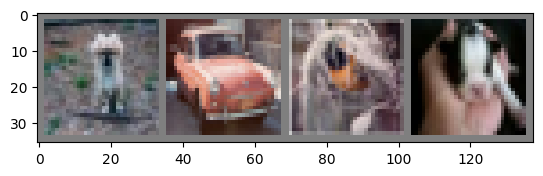

In [8]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))


In [9]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        # from 3 layers to 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        # for the record, in order to get the layer of 0's wrapping around the images, we need to add the parameter padding=1
        # without it, you will lose 2 pixels after each convolution, which is the source of many size conflicts 
        # from 64 to 64
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        # max pool
        self.pool = nn.MaxPool2d(2, 2)
        
        # 64 channels * 8 * 8 = 4096
        self.fc1 = nn.Linear(4096, 10)

    def forward(self, x):
        # 32x32
        x = F.relu(self.conv1(x))             # 32x32x64
        x = F.relu(self.conv2(x))             # 32x32x64
        x = self.pool(x)                      # 16x16x64
        
        # 16x16
        x = F.relu(self.conv2(x))             # 16x16x64
        x = self.pool(x)                      # 8x8x64
        
        # 8x8
        x = F.relu(self.conv2(x))             # 8x8x64
                                              # no pool here
        
        # then we flatten
        x = x.view(-1, 64 * 8 * 8)            # 4096 neurons
        
        # densification
        x = self.fc1(x)                       # 10 outputs
        
        # no softmax cuz taken into account with the cross entropy used afterwards
        return x

In [10]:
model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # origin shape: [4, 3, 32, 32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 2000 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

In [ ]:
print('Finished Training')
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        for i in range(batch_size):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {acc} %')